# Conditional matching analysis of learned edge selection

This notebook provides a direct visualization of conditional mask selection using only three existing within-user features: item degree percentile (`D`), visual affinity percentile (`V`), and textual affinity percentile (`T`).

Primary comparisons:

1. Hold both affinities near the middle (`V,T` in P40–P60), then compare high- versus low-degree edges.
2. Hold degree near the middle (`D` in P40–P60), then compare high- versus low-visual-affinity edges.
3. Hold degree near the middle (`D` in P40–P60), then compare high- versus low-textual-affinity edges.

Low and high mean the bottom and top quartiles. Confidence intervals use user-cluster bootstrap. This remains an associative analysis, not a causal estimate.

In [1]:
from pathlib import Path
import gc
from collections import OrderedDict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from scipy.stats import wilcoxon

if int(torch.__version__.split('.')[0]) < 2:
    raise RuntimeError('Select the explainable kernel with PyTorch >= 2.')

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', lambda value: f'{value:.6f}')

SEED = 999
N_BOOTSTRAP = 1000
N_SENSITIVITY_BOOTSTRAP = 500
MATCH_LOW = 0.40
MATCH_HIGH = 0.60
EXTREME_LOW = 0.25
EXTREME_HIGH = 0.75
MIXED_USERS_ONLY = True
RUN_STRICT_CROSS_MODAL_SENSITIVITY = True
RUN_WINDOW_SENSITIVITY = True
RUN_NAME = 'PGL_MASKED-baby-seed999-Sep-01-2026-04-06-39'

def find_src_dir():
    cwd = Path.cwd()
    candidates = [cwd, cwd / 'src', *cwd.parents]
    for candidate in candidates:
        if (candidate / 'saved').is_dir() and (candidate / 'mask_analysis').is_dir():
            return candidate
    raise FileNotFoundError('Cannot locate PGL/src from the current directory.')

SRC_DIR = find_src_dir()
ANALYSIS_PATH = SRC_DIR / 'saved' / f'{RUN_NAME}-analysis.pt'
CHECKPOINT_PATH = SRC_DIR / 'saved' / f'{RUN_NAME}.pth'
assert ANALYSIS_PATH.is_file(), ANALYSIS_PATH
assert CHECKPOINT_PATH.is_file(), CHECKPOINT_PATH

print('PyTorch:', torch.__version__)
print('Analysis:', ANALYSIS_PATH)
print('Checkpoint:', CHECKPOINT_PATH)
print(f'Match window: P{MATCH_LOW * 100:.0f}–P{MATCH_HIGH * 100:.0f}')
print(f'Extreme groups: <=P{EXTREME_LOW * 100:.0f} and >=P{EXTREME_HIGH * 100:.0f}')

PyTorch: 2.2.1+cu118
Analysis: c:\study\Master_papers\code\multimodal_RS\PGL\src\saved\PGL_MASKED-baby-seed999-Sep-01-2026-04-06-39-analysis.pt
Checkpoint: c:\study\Master_papers\code\multimodal_RS\PGL\src\saved\PGL_MASKED-baby-seed999-Sep-01-2026-04-06-39.pth
Match window: P40–P60
Extreme groups: <=P25 and >=P75


## 1. Reconstruct `D`, `V`, `T`, and the hard-mask target

The projection and normalization below exactly follow the existing mask-analysis notebook. The target is the final checkpoint's `selected_at_keep_ratio`.

In [2]:
analysis = torch.load(ANALYSIS_PATH, map_location='cpu', weights_only=False)
metadata = analysis['metadata']
mask_data = analysis['masks']['masked_branch']

user_ids = analysis['ui_edges']['user_ids'].long()
item_ids = analysis['ui_edges']['item_ids'].long()
mask_logits = mask_data['logits'].float()
mask_probability = mask_data['probabilities'].float()
selected = mask_data['selected_at_keep_ratio'].bool()

n_edges = metadata['num_interactions']
n_users = metadata['num_users']
n_items = metadata['num_items']
assert len(user_ids) == len(item_ids) == len(selected) == n_edges
assert torch.allclose(mask_probability, torch.sigmoid(mask_logits), atol=1e-7)
assert int(selected.sum()) == int(n_edges * metadata['mask_keep_ratio'])

edge_df = pd.DataFrame({
    'edge_id': np.arange(n_edges, dtype=np.int64),
    'user_id': user_ids.numpy(),
    'item_id': item_ids.numpy(),
    'selected': selected.numpy(),
})

del analysis, mask_data, user_ids, item_ids, mask_logits, mask_probability, selected
gc.collect()

print(f'Edges: {len(edge_df):,}')
print(f'Selected: {edge_df.selected.sum():,} ({edge_df.selected.mean():.2%})')
print(f'Users: {edge_df.user_id.nunique():,}')

Edges: 118,551
Selected: 35,565 (30.00%)
Users: 19,445


In [3]:
user_degree = np.bincount(edge_df.user_id, minlength=n_users)
item_degree = np.bincount(edge_df.item_id, minlength=n_items)
edge_df['user_degree'] = user_degree[edge_df.user_id.to_numpy()]
edge_df['item_degree'] = item_degree[edge_df.item_id.to_numpy()]

checkpoint = torch.load(CHECKPOINT_PATH, map_location='cpu', weights_only=False)
state = checkpoint['model_state_dict']
required_keys = {
    'second_user_image.weight', 'second_user_text.weight',
    'image_embedding.weight', 'text_embedding.weight',
    'image_trs.weight', 'image_trs.bias',
    'text_trs.weight', 'text_trs.bias',
}
missing_keys = required_keys.difference(state)
assert not missing_keys, f'Missing checkpoint keys: {sorted(missing_keys)}'

with torch.no_grad():
    user_visual = F.normalize(state['second_user_image.weight'].float(), dim=1)
    user_textual = F.normalize(state['second_user_text.weight'].float(), dim=1)
    item_visual = F.normalize(
        F.linear(
            state['image_embedding.weight'].float(),
            state['image_trs.weight'].float(),
            state['image_trs.bias'].float(),
        ), dim=1,
    )
    item_textual = F.normalize(
        F.linear(
            state['text_embedding.weight'].float(),
            state['text_trs.weight'].float(),
            state['text_trs.bias'].float(),
        ), dim=1,
    )

assert user_visual.shape == user_textual.shape == (n_users, 64)
assert item_visual.shape == item_textual.shape == (n_items, 64)

edge_users = torch.from_numpy(edge_df.user_id.to_numpy(dtype=np.int64))
edge_items = torch.from_numpy(edge_df.item_id.to_numpy(dtype=np.int64))
with torch.no_grad():
    visual_similarity = (user_visual[edge_users] * item_visual[edge_items]).sum(dim=1)
    textual_similarity = (user_textual[edge_users] * item_textual[edge_items]).sum(dim=1)

edge_df['visual_similarity'] = visual_similarity.numpy()
edge_df['textual_similarity'] = textual_similarity.numpy()
assert np.isfinite(edge_df[['visual_similarity', 'textual_similarity']].to_numpy()).all()

del checkpoint, state, edge_users, edge_items, visual_similarity, textual_similarity
del user_visual, user_textual, item_visual, item_textual
gc.collect()

9

In [4]:
def within_user_percentile(frame, value_column):
    grouped = frame.groupby('user_id')[value_column]
    ranks = grouped.rank(method='average')
    sizes = grouped.transform('size')
    percentile = (ranks - 1.0) / (sizes - 1.0)
    return percentile.where(sizes.gt(1), 0.5)

edge_df['D'] = within_user_percentile(edge_df, 'item_degree')
edge_df['V'] = within_user_percentile(edge_df, 'visual_similarity')
edge_df['T'] = within_user_percentile(edge_df, 'textual_similarity')

label_variety = edge_df.groupby('user_id').selected.nunique()
mixed_users = label_variety.index[label_variety.eq(2)]
edge_df['mixed_user'] = edge_df.user_id.isin(mixed_users)
analysis_df = edge_df.loc[edge_df.mixed_user].copy() if MIXED_USERS_ONLY else edge_df.copy()

assert analysis_df[['D', 'V', 'T']].notna().all().all()
assert analysis_df[['D', 'V', 'T']].ge(0).all().all()
assert analysis_df[['D', 'V', 'T']].le(1).all().all()

print(f'Analysis edges: {len(analysis_df):,}')
print(f'Analysis users: {analysis_df.user_id.nunique():,}')
print(f'Selected rate: {analysis_df.selected.mean():.2%}')
print('Cohort:', 'mixed users only' if MIXED_USERS_ONLY else 'all users')
analysis_df[['user_id', 'item_id', 'D', 'V', 'T', 'selected']].head()

Analysis edges: 86,114
Analysis users: 12,922
Selected rate: 33.88%
Cohort: mixed users only


,user_id,item_id,D,V,T,selected
0,0,0,0.000000,0.500000,0.500000,True
1,0,1587,1.000000,0.000000,0.000000,False
2,0,1879,0.500000,1.000000,1.000000,True
14,4,3408,1.000000,0.000000,0.000000,True
15,4,5070,0.000000,1.000000,0.500000,True


## 2. Conditional comparison definitions

The degree comparison controls both modality affinities. The two affinity comparisons follow the requested simple visualization and control degree only. A later strict sensitivity additionally controls the non-focal modality.

In [5]:
PRIMARY_COMPARISONS = OrderedDict([
    ('Degree | V,T matched', {
        'focal': 'D', 'controlled': ['V', 'T'],
        'low_label': 'Low degree', 'high_label': 'High degree',
    }),
    ('Visual | D matched', {
        'focal': 'V', 'controlled': ['D'],
        'low_label': 'Low visual', 'high_label': 'High visual',
    }),
    ('Textual | D matched', {
        'focal': 'T', 'controlled': ['D'],
        'low_label': 'Low textual', 'high_label': 'High textual',
    }),
])

STRICT_COMPARISONS = OrderedDict([
    ('Degree | V,T matched', PRIMARY_COMPARISONS['Degree | V,T matched']),
    ('Visual | D,T matched', {
        'focal': 'V', 'controlled': ['D', 'T'],
        'low_label': 'Low visual', 'high_label': 'High visual',
    }),
    ('Textual | D,V matched', {
        'focal': 'T', 'controlled': ['D', 'V'],
        'low_label': 'Low textual', 'high_label': 'High textual',
    }),
])

pd.DataFrame([
    {'comparison': name, 'focal': spec['focal'], 'controlled': ', '.join(spec['controlled'])}
    for name, spec in PRIMARY_COMPARISONS.items()
]).set_index('comparison')

,focal,controlled
comparison,,
"Degree | V,T matched",D,"V, T"
Visual | D matched,V,D
Textual | D matched,T,D


In [6]:
def standardized_mean_difference(low_values, high_values):
    low_values = np.asarray(low_values, dtype=np.float64)
    high_values = np.asarray(high_values, dtype=np.float64)
    pooled_variance = (low_values.var(ddof=1) + high_values.var(ddof=1)) / 2.0
    if pooled_variance <= 0:
        return 0.0 if np.isclose(low_values.mean(), high_values.mean()) else np.nan
    return (high_values.mean() - low_values.mean()) / np.sqrt(pooled_variance)

def build_conditional_subset(frame, spec, match_low, match_high):
    matched = np.ones(len(frame), dtype=bool)
    for controlled_feature in spec['controlled']:
        matched &= frame[controlled_feature].between(match_low, match_high).to_numpy()

    focal = frame[spec['focal']].to_numpy()
    low_group = focal <= EXTREME_LOW
    high_group = focal >= EXTREME_HIGH
    keep = matched & (low_group | high_group)

    subset = frame.loc[keep, ['user_id', 'selected', 'D', 'V', 'T']].copy()
    subset['group'] = np.where(high_group[keep], 'high', 'low')
    return subset

def aggregate_user_group_counts(subset):
    aggregated = (
        subset.groupby(['user_id', 'group']).selected
        .agg(selected_edges='sum', edges='size')
        .reset_index()
    )
    selected_wide = aggregated.pivot(index='user_id', columns='group', values='selected_edges')
    count_wide = aggregated.pivot(index='user_id', columns='group', values='edges')
    for group in ['low', 'high']:
        if group not in selected_wide:
            selected_wide[group] = 0.0
            count_wide[group] = 0.0
    selected_wide = selected_wide[['low', 'high']].fillna(0.0)
    count_wide = count_wide[['low', 'high']].fillna(0.0)
    return pd.DataFrame({
        'low_selected': selected_wide.low,
        'low_edges': count_wide.low,
        'high_selected': selected_wide.high,
        'high_edges': count_wide.high,
    })

def safe_rate(selected_edges, total_edges):
    return selected_edges / total_edges if total_edges > 0 else np.nan

def rate_ratio_and_odds_ratio(low_selected, low_edges, high_selected, high_edges):
    low_rate = safe_rate(low_selected, low_edges)
    high_rate = safe_rate(high_selected, high_edges)
    risk_ratio = high_rate / low_rate if low_rate > 0 else np.nan
    low_unselected = low_edges - low_selected
    high_unselected = high_edges - high_selected
    if min(low_selected, low_unselected, high_selected, high_unselected) <= 0:
        odds_ratio = (
            (high_selected + 0.5) * (low_unselected + 0.5)
            / ((high_unselected + 0.5) * (low_selected + 0.5))
        )
    else:
        odds_ratio = (high_selected * low_unselected) / (high_unselected * low_selected)
    return risk_ratio, odds_ratio

def cluster_bootstrap_rates(user_counts, n_bootstrap, seed):
    values = user_counts[['low_selected', 'low_edges', 'high_selected', 'high_edges']].to_numpy()
    n_cluster = len(values)
    rng = np.random.default_rng(seed)
    draws = np.empty((n_bootstrap, 3), dtype=np.float64)
    for bootstrap_index in range(n_bootstrap):
        sampled_positions = rng.integers(0, n_cluster, size=n_cluster)
        totals = values[sampled_positions].sum(axis=0)
        low_rate = safe_rate(totals[0], totals[1])
        high_rate = safe_rate(totals[2], totals[3])
        draws[bootstrap_index] = [low_rate, high_rate, high_rate - low_rate]
    return draws

def analyse_comparison(
    frame, name, spec, match_low=MATCH_LOW, match_high=MATCH_HIGH,
    n_bootstrap=N_BOOTSTRAP, seed=SEED,
):
    subset = build_conditional_subset(frame, spec, match_low, match_high)
    if subset.empty or subset.group.nunique() != 2:
        raise RuntimeError(f'Comparison {name} has insufficient low/high edges.')

    low = subset.loc[subset.group.eq('low')]
    high = subset.loc[subset.group.eq('high')]
    low_selected, low_edges = int(low.selected.sum()), len(low)
    high_selected, high_edges = int(high.selected.sum()), len(high)
    low_rate = low_selected / low_edges
    high_rate = high_selected / high_edges
    risk_ratio, odds_ratio = rate_ratio_and_odds_ratio(
        low_selected, low_edges, high_selected, high_edges
    )

    user_counts = aggregate_user_group_counts(subset)
    bootstrap_draws = cluster_bootstrap_rates(user_counts, n_bootstrap, seed)
    low_ci = np.quantile(bootstrap_draws[:, 0], [0.025, 0.975])
    high_ci = np.quantile(bootstrap_draws[:, 1], [0.025, 0.975])
    difference_ci = np.quantile(bootstrap_draws[:, 2], [0.025, 0.975])

    paired = user_counts.loc[user_counts.low_edges.gt(0) & user_counts.high_edges.gt(0)].copy()
    paired['low_rate'] = paired.low_selected / paired.low_edges
    paired['high_rate'] = paired.high_selected / paired.high_edges
    paired['difference'] = paired.high_rate - paired.low_rate
    if len(paired) > 0 and not np.allclose(paired.difference, 0):
        paired_p_value = wilcoxon(paired.difference).pvalue
    else:
        paired_p_value = np.nan

    summary = {
        'comparison': name,
        'match_window': f'P{match_low * 100:.0f}–P{match_high * 100:.0f}',
        'controlled': ','.join(spec['controlled']),
        'low_label': spec['low_label'],
        'high_label': spec['high_label'],
        'low_edges': low_edges,
        'high_edges': high_edges,
        'low_users': low.user_id.nunique(),
        'high_users': high.user_id.nunique(),
        'low_selection_rate': low_rate,
        'high_selection_rate': high_rate,
        'risk_difference': high_rate - low_rate,
        'risk_difference_pp': 100.0 * (high_rate - low_rate),
        'risk_difference_ci_low': difference_ci[0],
        'risk_difference_ci_high': difference_ci[1],
        'risk_ratio': risk_ratio,
        'odds_ratio': odds_ratio,
        'paired_users': len(paired),
        'paired_mean_difference': paired.difference.mean() if len(paired) else np.nan,
        'paired_median_difference': paired.difference.median() if len(paired) else np.nan,
        'paired_wilcoxon_p_value': paired_p_value,
        'low_rate_ci_low': low_ci[0],
        'low_rate_ci_high': low_ci[1],
        'high_rate_ci_low': high_ci[0],
        'high_rate_ci_high': high_ci[1],
    }

    balance_rows = []
    for controlled_feature in spec['controlled']:
        smd = standardized_mean_difference(low[controlled_feature], high[controlled_feature])
        balance_rows.append({
            'comparison': name,
            'controlled_feature': controlled_feature,
            'low_mean': low[controlled_feature].mean(),
            'high_mean': high[controlled_feature].mean(),
            'standardized_mean_difference': smd,
            'absolute_smd': abs(smd),
        })

    return summary, pd.DataFrame(balance_rows), bootstrap_draws, subset, paired

## 3. Primary P40–P60 conditional comparisons

The principal quantity is the absolute risk difference:

`Delta P = P(selected | high) - P(selected | low)`.

A positive degree difference supports the conditional positive degree coefficient. Larger visual/textual differences support affinity as the dominant selection signal.

In [9]:
primary_rows = []
primary_balance_frames = []
primary_bootstrap = {}
primary_subsets = {}
primary_paired = {}

for comparison_index, (name, spec) in enumerate(PRIMARY_COMPARISONS.items()):
    summary, balance, bootstrap_draws, subset, paired = analyse_comparison(
        analysis_df, name, spec, seed=SEED + comparison_index
    )
    primary_rows.append(summary)
    primary_balance_frames.append(balance)
    primary_bootstrap[name] = bootstrap_draws
    primary_subsets[name] = subset
    primary_paired[name] = paired

primary_summary = pd.DataFrame(primary_rows).set_index('comparison')
primary_balance = pd.concat(primary_balance_frames, ignore_index=True)
primary_summary[[
    'controlled', 'low_edges', 'high_edges',
    'low_selection_rate', 'high_selection_rate',
    'risk_difference_pp', 'risk_difference_ci_low', 'risk_difference_ci_high',
    'risk_ratio', 'odds_ratio',
]]

,controlled,low_edges,high_edges,low_selection_rate,high_selection_rate,risk_difference_pp,risk_difference_ci_low,risk_difference_ci_high,risk_ratio,odds_ratio
comparison,,,,,,,,,,
"Degree | V,T matched","V,T",1208,1037,0.364238,0.469624,10.538550,0.062584,0.145659,1.289331,1.545521
Visual | D matched,D,4441,4832,0.258275,0.413700,15.542517,0.136576,0.173957,1.601781,2.026406
Textual | D matched,D,4084,4810,0.190989,0.471102,28.011264,0.262619,0.297571,2.466641,3.773012


In [10]:
print('Balance guideline: |SMD| < 0.10 is commonly treated as good descriptive balance.')
primary_balance.set_index(['comparison', 'controlled_feature'])

Balance guideline: |SMD| < 0.10 is commonly treated as good descriptive balance.


low_mean  high_mean  \
comparison           controlled_feature                        
Degree | V,T matched V                   0.503435   0.494153   
                     T                   0.507317   0.492491   
Visual | D matched   D                   0.506912   0.495933   
Textual | D matched  D                   0.508256   0.493982   

                                         standardized_mean_difference  \
comparison           controlled_feature                                 
Degree | V,T matched V                                      -0.153255   
                     T                                      -0.244997   
Visual | D matched   D                                      -0.193961   
Textual | D matched  D                                      -0.251090   

                                         absolute_smd  
comparison           controlled_feature                
Degree | V,T matched V                       0.153255  
                     T                       0.244997  
Visual | D matched   D                       0.193961  
Textual | D matched  D                       0.251090

In [11]:
primary_summary[[
    'paired_users', 'paired_mean_difference',
    'paired_median_difference', 'paired_wilcoxon_p_value',
]]

,paired_users,paired_mean_difference,paired_median_difference,paired_wilcoxon_p_value
comparison,,,,
"Degree | V,T matched",53,0.169811,0.000000,0.071861
Visual | D matched,1051,0.162813,0.000000,0.000000
Textual | D matched,962,0.253430,0.000000,0.000000


## 4. Reviewer-ready visualization

Bars show conditional selection rates. Error bars are user-cluster bootstrap 95% confidence intervals. The forest plot compares effect sizes on the same percentage-point scale.

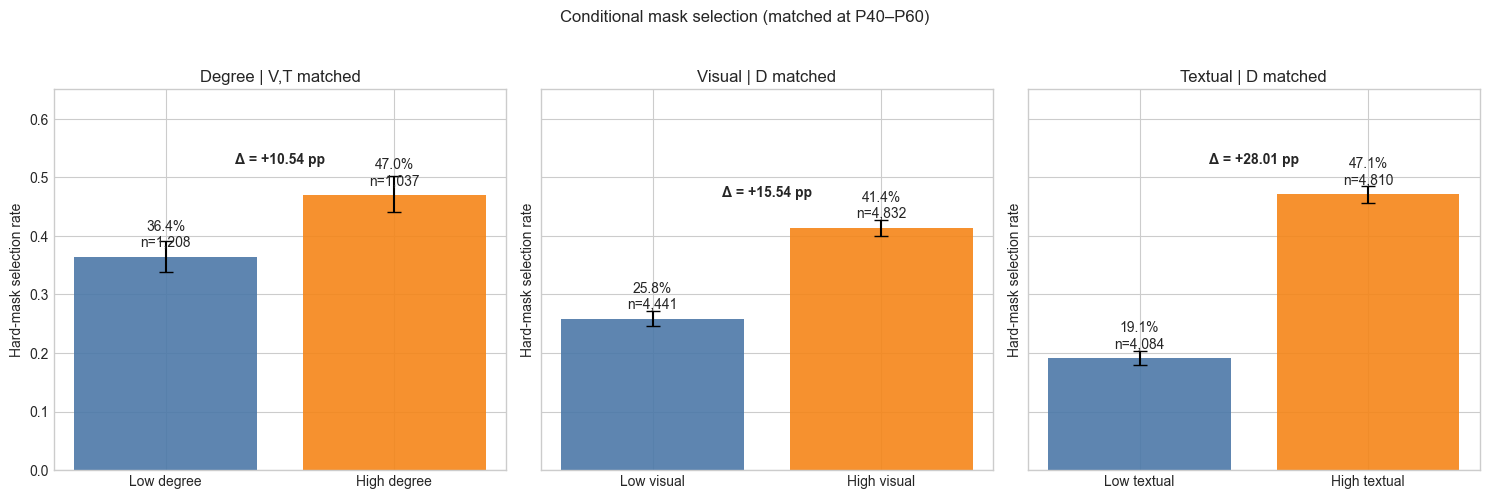

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharey=True)
colors = ['#4C78A8', '#F58518']

for axis, (name, row) in zip(axes, primary_summary.iterrows()):
    rates = np.array([row.low_selection_rate, row.high_selection_rate])
    lower_error = rates - np.array([row.low_rate_ci_low, row.high_rate_ci_low])
    upper_error = np.array([row.low_rate_ci_high, row.high_rate_ci_high]) - rates
    axis.bar(
        [0, 1], rates, color=colors, alpha=0.9,
        yerr=np.vstack([lower_error, upper_error]), capsize=5,
    )
    axis.set_xticks([0, 1], [row.low_label, row.high_label])
    axis.set_ylim(0, max(0.65, rates.max() + 0.12))
    axis.set_title(name)
    axis.set_ylabel('Hard-mask selection rate')
    axis.text(
        0.5, max(rates) + 0.06,
        f'Δ = {row.risk_difference_pp:+.2f} pp',
        ha='center', va='center', fontweight='bold',
    )
    for position, rate, edge_count in zip([0, 1], rates, [row.low_edges, row.high_edges]):
        axis.text(position, rate + 0.012, f'{rate:.1%}\nn={int(edge_count):,}', ha='center', va='bottom')

fig.suptitle(
    f'Conditional mask selection (matched at P{MATCH_LOW * 100:.0f}–P{MATCH_HIGH * 100:.0f})',
    y=1.03,
)
plt.tight_layout()
plt.show()

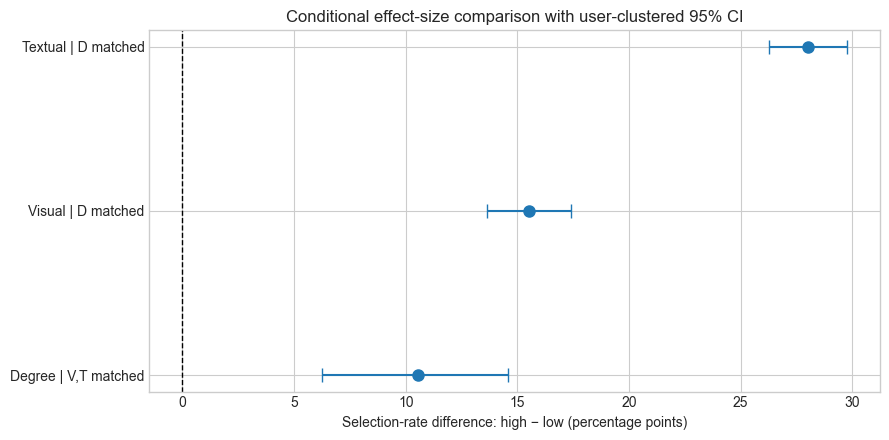

In [13]:
forest = primary_summary.copy()
forest['ci_low_pp'] = 100.0 * forest.risk_difference_ci_low
forest['ci_high_pp'] = 100.0 * forest.risk_difference_ci_high
positions = np.arange(len(forest))

fig, axis = plt.subplots(figsize=(9, 4.5))
axis.errorbar(
    forest.risk_difference_pp, positions,
    xerr=[
        forest.risk_difference_pp - forest.ci_low_pp,
        forest.ci_high_pp - forest.risk_difference_pp,
    ],
    fmt='o', markersize=8, capsize=5, color='tab:blue',
)
axis.axvline(0, color='black', linestyle='--', linewidth=1)
axis.set_yticks(positions, forest.index)
axis.set(
    xlabel='Selection-rate difference: high − low (percentage points)',
    title='Conditional effect-size comparison with user-clustered 95% CI',
)
plt.tight_layout()
plt.show()

## 5. Strict cross-modal sensitivity

The simple visual comparison fixes degree only, and the simple textual comparison also fixes degree only. This sensitivity additionally fixes the other modality in P40–P60, reducing cross-modal confounding at the cost of fewer edges.

In [14]:
if RUN_STRICT_CROSS_MODAL_SENSITIVITY:
    strict_rows = []
    strict_balance_frames = []
    for comparison_index, (name, spec) in enumerate(STRICT_COMPARISONS.items()):
        summary, balance, _, _, _ = analyse_comparison(
            analysis_df, name, spec, seed=SEED + 100 + comparison_index
        )
        strict_rows.append(summary)
        strict_balance_frames.append(balance)
    strict_summary = pd.DataFrame(strict_rows).set_index('comparison')
    strict_balance = pd.concat(strict_balance_frames, ignore_index=True)
    display(strict_summary[[
        'controlled', 'low_edges', 'high_edges',
        'low_selection_rate', 'high_selection_rate',
        'risk_difference_pp', 'risk_difference_ci_low', 'risk_difference_ci_high',
        'risk_ratio', 'odds_ratio',
    ]])
    display(strict_balance.set_index(['comparison', 'controlled_feature']))
else:
    strict_summary = None
    strict_balance = None
    print('Strict cross-modal sensitivity disabled.')

,controlled,low_edges,high_edges,low_selection_rate,high_selection_rate,risk_difference_pp,risk_difference_ci_low,risk_difference_ci_high,risk_ratio,odds_ratio
comparison,,,,,,,,,,
"Degree | V,T matched","V,T",1208,1037,0.364238,0.469624,10.538550,0.066942,0.145123,1.289331,1.545521
"Visual | D,T matched","D,T",1353,1387,0.266075,0.405912,13.983665,0.105759,0.173525,1.525553,1.884638
"Textual | D,V matched","D,V",1174,1377,0.184838,0.465505,28.066656,0.245293,0.314153,2.518445,3.840895


low_mean  high_mean  \
comparison            controlled_feature                        
Degree | V,T matched  V                   0.503435   0.494153   
                      T                   0.507317   0.492491   
Visual | D,T matched  D                   0.505715   0.495442   
                      T                   0.502174   0.498792   
Textual | D,V matched D                   0.506457   0.492228   
                      V                   0.493705   0.500392   

                                          standardized_mean_difference  \
comparison            controlled_feature                                 
Degree | V,T matched  V                                      -0.153255   
                      T                                      -0.244997   
Visual | D,T matched  D                                      -0.175242   
                      T                                      -0.056659   
Textual | D,V matched D                                      -0.240123   
                      V                                       0.111308   

                                          absolute_smd  
comparison            controlled_feature                
Degree | V,T matched  V                       0.153255  
                      T                       0.244997  
Visual | D,T matched  D                       0.175242  
                      T                       0.056659  
Textual | D,V matched D                       0.240123  
                      V                       0.111308

## 6. Matching-window sensitivity

The conclusion should not depend entirely on choosing P40–P60. This section repeats the three primary comparisons at P35–P65, P40–P60, and P45–P55. Narrower windows improve similarity of controlled features but reduce sample size.

In [15]:
if RUN_WINDOW_SENSITIVITY:
    matching_windows = [(0.35, 0.65), (0.40, 0.60), (0.45, 0.55)]
    sensitivity_rows = []
    for window_index, (match_low, match_high) in enumerate(matching_windows):
        for comparison_index, (name, spec) in enumerate(PRIMARY_COMPARISONS.items()):
            summary, _, _, _, _ = analyse_comparison(
                analysis_df, name, spec,
                match_low=match_low, match_high=match_high,
                n_bootstrap=N_SENSITIVITY_BOOTSTRAP,
                seed=SEED + 1000 + window_index * 10 + comparison_index,
            )
            sensitivity_rows.append(summary)
    window_sensitivity = pd.DataFrame(sensitivity_rows)
    display(window_sensitivity[[
        'comparison', 'match_window', 'low_edges', 'high_edges',
        'low_selection_rate', 'high_selection_rate',
        'risk_difference_pp', 'risk_difference_ci_low', 'risk_difference_ci_high',
    ]])
else:
    window_sensitivity = None
    print('Matching-window sensitivity disabled.')

,comparison,match_window,low_edges,high_edges,low_selection_rate,high_selection_rate,risk_difference_pp,risk_difference_ci_low,risk_difference_ci_high
0,"Degree | V,T matched",P35–P65,1632,1433,0.321691,0.432659,11.096758,0.077241,0.146398
1,Visual | D matched,P35–P65,5489,5836,0.245218,0.404729,15.951156,0.142397,0.175277
2,Textual | D matched,P35–P65,5098,5791,0.186544,0.460024,27.348043,0.257769,0.289112
3,"Degree | V,T matched",P40–P60,1208,1037,0.364238,0.469624,10.538550,0.066209,0.147145
4,Visual | D matched,P40–P60,4441,4832,0.258275,0.413700,15.542517,0.136480,0.174763
5,Textual | D matched,P40–P60,4084,4810,0.190989,0.471102,28.011264,0.262880,0.299005
6,"Degree | V,T matched",P45–P55,633,505,0.470774,0.487129,1.635462,-0.049285,0.071476
7,Visual | D matched,P45–P55,2618,2847,0.296409,0.446786,15.037662,0.127054,0.175361
8,Textual | D matched,P45–P55,2302,2907,0.221112,0.500860,27.974792,0.256751,0.303601


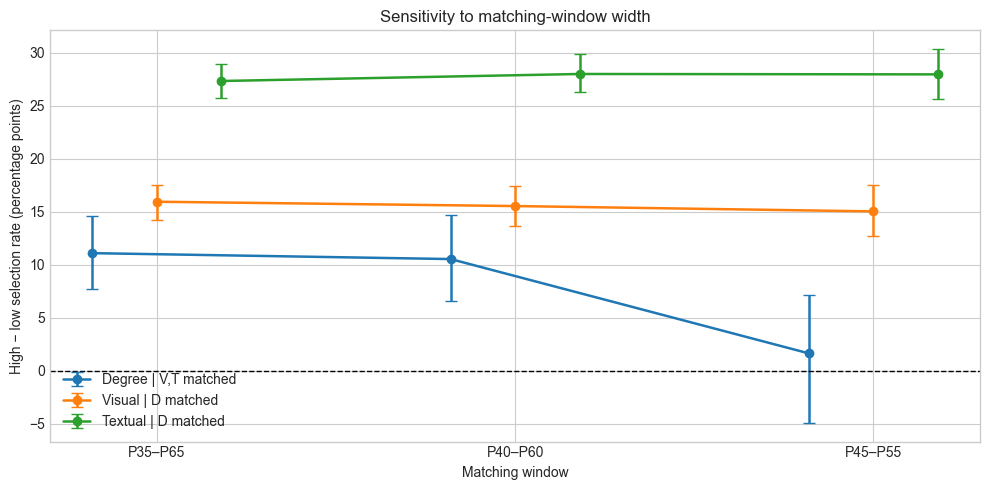

In [16]:
if window_sensitivity is not None:
    fig, axis = plt.subplots(figsize=(10, 5))
    window_order = ['P35–P65', 'P40–P60', 'P45–P55']
    x = np.arange(len(window_order))
    offsets = np.linspace(-0.18, 0.18, len(PRIMARY_COMPARISONS))

    for offset, (name, _) in zip(offsets, PRIMARY_COMPARISONS.items()):
        subset = (
            window_sensitivity.loc[window_sensitivity.comparison.eq(name)]
            .set_index('match_window').reindex(window_order)
        )
        estimate = subset.risk_difference_pp.to_numpy()
        ci_low = 100.0 * subset.risk_difference_ci_low.to_numpy()
        ci_high = 100.0 * subset.risk_difference_ci_high.to_numpy()
        axis.errorbar(
            x + offset, estimate,
            yerr=[estimate - ci_low, ci_high - estimate],
            marker='o', capsize=4, linewidth=1.8, label=name,
        )

    axis.axhline(0, color='black', linestyle='--', linewidth=1)
    axis.set_xticks(x, window_order)
    axis.set(
        xlabel='Matching window',
        ylabel='High − low selection rate (percentage points)',
        title='Sensitivity to matching-window width',
    )
    axis.legend()
    plt.tight_layout()
    plt.show()

## 7. Interpretation rules

A transparent interpretation should use all of the following:

- Direction and size of the high-minus-low selection-rate difference.
- User-cluster bootstrap CI: whether it excludes zero.
- Sample sizes in both extreme groups.
- Balance diagnostics for controlled features; absolute SMD below 0.10 is a useful descriptive target.
- Stability across P35–P65, P40–P60, and P45–P55.
- Paired-user sensitivity, recognizing that it uses fewer users and may be noisier.

If degree remains positive while visual and textual affinity differences are substantially larger, the result supports: `Affinity controlled: high degree > low degree`, but affinity remains the dominant selection signal. Restricting values to a percentile window reduces observed confounding; it does not prove causal effects because mask and affinities were learned jointly.

In [ ]:
SAVE_RESULTS = False
if SAVE_RESULTS:
    output_dir = SRC_DIR / 'mask_analysis' / 'conditional_matching_results'
    output_dir.mkdir(parents=True, exist_ok=True)
    primary_summary.to_csv(output_dir / 'primary_summary.csv')
    primary_balance.to_csv(output_dir / 'primary_balance.csv', index=False)
    if strict_summary is not None:
        strict_summary.to_csv(output_dir / 'strict_cross_modal_summary.csv')
        strict_balance.to_csv(output_dir / 'strict_cross_modal_balance.csv', index=False)
    if window_sensitivity is not None:
        window_sensitivity.to_csv(output_dir / 'window_sensitivity.csv', index=False)
    print('Saved results to:', output_dir)
else:
    print('Set SAVE_RESULTS = True to export result tables.')